# Lecture 17 — Generative Adversarial Networks

**CMU 10-414/714, Deep Learning Systems (lecture by Tianqi Chen)**
Companion notebook · Sangram Lembe

The theory lecture behind the GAN implementation in Lecture 18. Each idea is demonstrated rather than
asserted:

1. why simple statistics are a poor distance between two collections — and a classifier is better
2. the **oracle** thought experiment, used to actually train a generator
3. why the generator flips the label in practice: a 100× stronger gradient
4. transposed convolutions, the upsampling layer in DCGAN, and why they are called "transposed"
5. CycleGAN's cycle-consistency loss catching what a GAN loss alone cannot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
rng = np.random.default_rng(0)

## 1. A distance between two collections

A generator is judged on its whole *collection* of samples. The obvious distance compares statistics such
as the mean and variance. Here are two distributions with the same of both:

one bump : mean -0.015  variance 0.997
two bumps: mean +0.031  variance 1.009


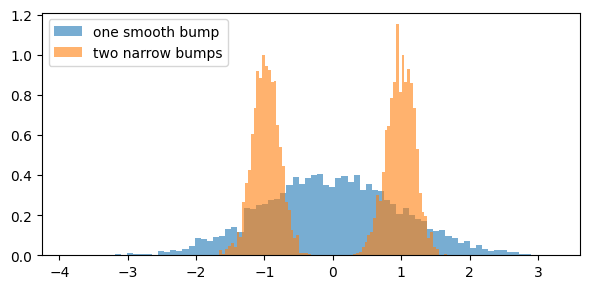

In [2]:
n = 4000
smooth = rng.normal(0, 1, n)                                   # one smooth bump
c = 0.98
bumps = rng.choice([-c, c], n) + rng.normal(0, np.sqrt(1 - c * c), n)   # two narrow bumps

print(f"one bump : mean {smooth.mean():+.3f}  variance {smooth.var():.3f}")
print(f"two bumps: mean {bumps.mean():+.3f}  variance {bumps.var():.3f}")

plt.figure(figsize=(6, 3))
plt.hist(smooth, bins=80, alpha=0.6, density=True, label="one smooth bump")
plt.hist(bumps, bins=80, alpha=0.6, density=True, label="two narrow bumps")
plt.legend(); plt.tight_layout(); plt.show()

Any loss built from mean and variance calls these identical. A small classifier does not:

In [3]:
X = np.r_[smooth, bumps].reshape(-1, 1)
y = np.r_[np.zeros(n), np.ones(n)]
idx = rng.permutation(2 * n)
X, y = X[idx], y[idx]
clf = MLPClassifier((16,), max_iter=3000, random_state=0).fit(X[:6000], y[:6000])
print(f"classifier telling the two apart on unseen samples: {clf.score(X[6000:], y[6000:]):.1%}  (guessing: 50%)")

classifier telling the two apart on unseen samples: 79.9%  (guessing: 50%)


That is the insight behind GANs: a *learned classifier* is a far better judge of "do these come from the
same place?" than a fixed formula.

## 2. The oracle thought experiment

Suppose an oracle discriminator existed. For two known 1-D Gaussians it does: the best possible
discriminator between real data $p$ and generated data $q$ is $D^*(x) = p(x) / (p(x) + q(x))$.

Let the real data be $\mathcal N(3, 1)$ and the generator $G(z) = z + \theta$, starting at $\theta = 0$.
Each step, ask the oracle about the current generator, then move $\theta$ to fool it.

In [4]:
def normal_pdf(x, m):
    return np.exp(-0.5 * (x - m) ** 2) / np.sqrt(2 * np.pi)

def oracle(theta):
    """The best discriminator for the CURRENT generator: real data N(3,1) vs fakes N(theta,1)."""
    return lambda x: normal_pdf(x, 3.0) / (normal_pdf(x, 3.0) + normal_pdf(x, theta))

theta, lr, history = 0.0, 0.5, []
z = rng.normal(0, 1, 2000)
for step in range(40):
    D = oracle(theta)                                # oracle frozen during the generator step
    loss = lambda t: np.mean(-np.log(D(z + t)))      # generator wants D(G(z)) -> 1
    eps = 1e-4
    grad = (loss(theta + eps) - loss(theta - eps)) / (2 * eps)
    theta -= lr * grad
    history.append(theta)

print("theta every 5 steps:", [round(float(t), 3) for t in history[::5]], "-> target 3.0")
print("oracle's verdict on fakes at the end:", round(float(np.mean(oracle(theta)(z + theta))), 3))

theta every 5 steps: [1.355, 2.714, 2.933, 2.984, 2.996, 2.999, 3.0, 3.0] -> target 3.0
oracle's verdict on fakes at the end: 0.5


The generator walks to the real mean, and at the end the oracle answers $\tfrac12$ for everything — it can
no longer tell real from fake, so it gives no more push. No oracle exists for real data, so a GAN *learns*
the discriminator alongside the generator — the full loop is Lecture 18.

## 3. Why the generator flips the label

Literally, the generator minimises $\log(1 - D(G(z)))$. In practice it maximises $\log D(G(z))$ — in code,
labelling its fakes "real". Compare the gradients with respect to the discriminator's final score (its
logit), for fakes the discriminator confidently rejects:

In [5]:
sigmoid = lambda a: 1 / (1 + np.exp(-a))
print(f"{'D(G(z))':>9}{'original loss grad':>21}{'flipped loss grad':>20}")
for p in (0.01, 0.1, 0.5, 0.9):
    a = np.log(p / (1 - p))                          # the logit that gives D = p
    print(f"{p:>9}{sigmoid(a):>21.3f}{1 - sigmoid(a):>20.3f}")

  D(G(z))   original loss grad   flipped loss grad
     0.01                0.010               0.990
      0.1                0.100               0.900
      0.5                0.500               0.500
      0.9                0.900               0.100


When the generator is bad and $D(G(z)) = 0.01$, the original loss passes back almost nothing (0.01),
while the flipped one passes back 0.99 — strongest exactly when the generator most needs to learn.

## 4. Transposed convolution: how DCGAN grows an image

A DCGAN generator turns a short vector into a big image with *transposed convolutions*: insert zeros
between the pixels, then convolve. Below, a stride-2 convolution shrinks $8\times8$ to $4\times4$, and its
transposed version grows $4\times4$ back to $8\times8$.

In [6]:
def conv_stride2(x, w):
    """3x3 convolution, padding 1, stride 2: halves the size."""
    xp = np.pad(x, 1)
    m = x.shape[0] // 2
    return np.array([[np.sum(xp[2*i:2*i+3, 2*j:2*j+3] * w) for j in range(m)] for i in range(m)])

def conv_transpose_stride2(y, w, out_size):
    """Insert zeros (dilate), pad, convolve with the flipped filter: doubles the size."""
    z = np.zeros((2 * y.shape[0], 2 * y.shape[1]))
    z[::2, ::2] = y                                   # spread out with zeros
    zp = np.pad(z, 1)
    wf = w[::-1, ::-1]
    return np.array([[np.sum(zp[i:i+3, j:j+3] * wf) for j in range(out_size)] for i in range(out_size)])

w = rng.normal(size=(3, 3))
x8, y4 = rng.normal(size=(8, 8)), rng.normal(size=(4, 4))
print("strided conv     :", x8.shape, "->", conv_stride2(x8, w).shape)
print("transposed conv  :", y4.shape, "->", conv_transpose_stride2(y4, w, 8).shape)

strided conv     : (8, 8) -> (4, 4)
transposed conv  : (4, 4) -> (8, 8)


Why "transposed"? A transpose $A^{\mathsf T}$ is defined by $\langle Ax, y\rangle = \langle x, A^{\mathsf T}y\rangle$
for every $x$ and $y$. Check it — the same fact as Day 8's flipped-filter result, now with a stride:

In [7]:
lhs = np.sum(conv_stride2(x8, w) * y4)
rhs = np.sum(x8 * conv_transpose_stride2(y4, w, 8))
print(f"<conv(x), y>   = {lhs:.10f}")
print(f"<x, convT(y)>  = {rhs:.10f}")
print("equal:", np.isclose(lhs, rhs))

sizes, s = [], 4
for _ in range(3):
    s *= 2; sizes.append(s)
print("\na DCGAN-style generator doubling three times: 4x4 ->", " -> ".join(f"{t}x{t}" for t in sizes))

<conv(x), y>   = -0.3379974990
<x, convT(y)>  = -0.3379974990
equal: True

a DCGAN-style generator doubling three times: 4x4 -> 8x8 -> 16x16 -> 32x32


## 5. CycleGAN: what a GAN loss cannot see

Translate between two unpaired domains: $X$ is standard 2-D Gaussian data, $Y$ is the same data scaled and
shifted, $y = 2x + 1$. Compare two translators $X \to Y$. The first maps each point to its true partner.
The second also rotates first. A GAN loss only checks that the outputs *look like* $Y$ as a collection:

In [8]:
Xd = rng.normal(size=(5000, 2))
th = 1.0
R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
G_true    = lambda x: 2 * x + 1
G_rotated = lambda x: 2 * (x @ R.T) + 1
F_back    = lambda y: (y - 1) / 2                     # translator Y -> X

for name, G in [("true partner", G_true), ("rotated first", G_rotated)]:
    Yh = G(Xd)
    cycle = np.abs(F_back(Yh) - Xd).mean()            # cycle-consistency: L1 distance
    print(f"{name:<14}: output mean {np.round(Yh.mean(0), 2)}  covariance {np.round(np.cov(Yh.T), 1).tolist()}"
          f"   cycle loss {cycle:.3f}")

true partner  : output mean [1. 1.]  covariance [[3.9, -0.0], [-0.0, 4.0]]   cycle loss 0.000
rotated first : output mean [1. 1.]  covariance [[4.0, -0.0], [-0.0, 3.9]]   cycle loss 0.760


Both translators produce outputs with the same mean and covariance, so a GAN loss on $Y$ is equally happy
with either — the rotated one turns each point into a valid-looking $Y$ that has nothing to do with its
input. Only the cycle-consistency loss, $F(G(x)) \approx x$, tells them apart: 0 for the true translator,
about 0.76 for the rotated one. That is why CycleGAN needs both kinds of loss.

## Summary

- Two distributions with identical mean and variance were told apart 80% of the time by a small classifier.
- With an oracle discriminator, the generator moved from $\theta=0$ to the real mean 3, where the oracle
  could only answer $\tfrac12$.
- Flipping the label gives the generator a gradient of 0.99 instead of 0.01 when its fakes are rejected.
- A transposed convolution doubles image size, and satisfies $\langle Ax,y\rangle = \langle x,A^{\mathsf T}y\rangle$ exactly.
- A GAN loss could not distinguish a faithful translator from a scrambling one; the cycle loss could.